# Module 3 — Anomaly Detection
## Notebook 1 — Data Preparation 

This version reads the **Module 3-only anomaly-enhanced dataset** from:

```text
../datasets/module3_anomaly/
```

The original shared datasets remain unchanged for the other modules.

## 1. Imports and paths

The path style follows your Module 4 notebook style.

In [2]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# -----------------------------------------------------------------------------
# Directory configuration — Module 3-only anomaly-enhanced dataset
# -----------------------------------------------------------------------------
INPUT_DIR = '../datasets/module3_anomaly'

POS_PATH = f'{INPUT_DIR}/enterprise_pos_dataset.csv'
ANOMALIES_PATH = f'{INPUT_DIR}/anomalies_ground_truth.csv'
CASHIERS_PATH = f'{INPUT_DIR}/cashiers.csv'
CUSTOMERS_PATH = f'{INPUT_DIR}/customers.csv'
DAILY_DEMAND_PATH = f'{INPUT_DIR}/daily_item_demand.csv'

OUTPUT_DIR = '../Data Preparation'
FEATURES_PATH = '../Data Preparation/order_level_anomaly_dataset.csv'
SCHEMA_PATH = '../Data Preparation/anomaly_feature_schema.json'

MODEL_DIR = '../Data Preparation/models'
FIGURE_DIR = '../Data Preparation/figures'
REPORT_DIR = '../Data Preparation'

for directory in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, REPORT_DIR]:
    Path(directory).mkdir(parents=True, exist_ok=True)

print('INPUT_DIR:', INPUT_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)


INPUT_DIR: ../datasets/module3_anomaly
OUTPUT_DIR: ../Data Preparation


## 2. Load datasets

Important: `enterprise_pos_dataset.csv` is pipe-separated, so we load it with `sep='|'`.

In [3]:
def check_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"File not found: {path}\n"
            "This notebook should be inside 'Module 3 Data Preparation' and the data should be in '../datasets'."
        )
    return path

for path in [POS_PATH, ANOMALIES_PATH, CASHIERS_PATH, CUSTOMERS_PATH, DAILY_DEMAND_PATH]:
    check_file(path)

pos = pd.read_csv(POS_PATH, sep='|')
anomalies = pd.read_csv(ANOMALIES_PATH)
cashiers = pd.read_csv(CASHIERS_PATH)
customers = pd.read_csv(CUSTOMERS_PATH)
daily_demand = pd.read_csv(DAILY_DEMAND_PATH)

print('POS line-level shape:', pos.shape)
print('Anomalies shape:', anomalies.shape)
print('Cashiers shape:', cashiers.shape)
print('Customers shape:', customers.shape)
print('Daily demand shape:', daily_demand.shape)

POS line-level shape: (180519, 17)
Anomalies shape: (1110, 3)
Cashiers shape: (12, 3)
Customers shape: (10000, 10)
Daily demand shape: (133712, 8)


In [4]:
display(pos.head())
display(anomalies.head())
display(cashiers.head())
display(customers.head())
display(daily_demand.head())

,order_details_id,order_id,order_date,order_time,item_name,category,price,restaurant_type,item_id,customer_id,cashier_id,payment_method,table_number,is_voided,void_reason,discount_pct,line_total
0,500000,100000,2023-01-01,07:30 AM,Oatmeal with Berries,Food,5.50,Cafe,80,520,C02,card,12.0,False,NaN,0.0,5.50
1,500001,100000,2023-01-01,07:30 AM,Cold Brew Coffee,Beverage,4.50,Cafe,35,520,C02,card,12.0,False,NaN,0.0,4.50
2,500002,100000,2023-01-01,07:30 AM,Fruit Smoothie,Beverage,6.50,Cafe,50,520,C02,card,12.0,False,NaN,0.0,6.50
3,500003,100001,2023-01-01,08:00 AM,Almond Croissant,Bakery,4.25,Cafe,4,6381,C03,cash,21.0,False,NaN,0.0,4.25
4,500004,100001,2023-01-01,08:00 AM,Everything Bagel with Cream Cheese,Bakery,4.50,Cafe,46,6381,C03,cash,21.0,False,NaN,0.0,4.50


,order_id,anomaly_type,description
0,147479,void_after_payment,Paid order voided with weak reason
1,121532,void_after_payment,Paid order voided with weak reason
2,141042,void_after_payment,Paid order voided with weak reason
3,109389,void_after_payment,Paid order voided with weak reason
4,157293,void_after_payment,Paid order voided with weak reason


,cashier_id,shift,flagged
0,C01,morning,False
1,C02,morning,False
2,C03,morning,False
3,C04,morning,False
4,C05,afternoon,False


,customer_id,archetype,price_tier,time_preference,day_preference,basket_size_bias,preferred_sections,preferred_categories,expected_visits,actual_visits
0,5485,infrequent,premium,dinner,weekday,small,Steakhouse,"Alcohol,Side",2,2
1,7761,infrequent,budget,dinner,weekday,large,"Steakhouse,Mexican","Alcohol,Main",4,4
2,1774,occasional,budget,lunch,weekday,large,"Healthy_Vegan,American","Bakery,Beverage",5,5
3,3417,occasional,premium,dinner,any,medium,Japanese,"Alcohol,Dessert",6,6
4,447,regular,premium,morning,any,medium,Cafe,"Appetizer,Food,Dessert",22,16


,order_date,item_name,quantity,section,category,avg_price,item_id,split
0,2023-01-01,14oz Ribeye,2,Steakhouse,Main,32.00,1,train
1,2023-01-01,8oz Filet Mignon,5,Steakhouse,Main,35.00,2,train
2,2023-01-01,Acai Berry Bowl,1,Healthy_Vegan,Food,9.50,3,train
3,2023-01-01,Almond Croissant,6,Cafe,Bakery,4.25,4,train
4,2023-01-01,Apple Pie,0,American,Dessert,5.00,5,train


## 3. Basic audit

In [5]:
def audit_dataframe(name, df):
    print(f"\n{name}")
    print('-' * len(name))
    print('Shape:', df.shape)
    print('Duplicate rows:', df.duplicated().sum())
    missing = df.isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0]
    if len(missing) == 0:
        print('Missing values: none')
    else:
        display(missing.to_frame('missing_count'))

for name, df in [
    ('POS', pos),
    ('Anomalies', anomalies),
    ('Cashiers', cashiers),
    ('Customers', customers),
    ('Daily demand', daily_demand),
]:
    audit_dataframe(name, df)

print('\nUnique orders:', pos['order_id'].nunique())
print('Unique order lines:', pos['order_details_id'].nunique())
print('Unique items:', pos['item_id'].nunique())
print('Unique cashiers:', pos['cashier_id'].nunique())
print('Unique customers:', pos['customer_id'].nunique())

print('\nGround truth anomaly types:')
display(anomalies['anomaly_type'].value_counts().to_frame('count'))

anomaly_order_count = anomalies['order_id'].nunique()
total_order_count = pos['order_id'].nunique()
print(f'\nLabeled anomalous orders: {anomaly_order_count:,}')
print(f'Anomaly rate: {anomaly_order_count / total_order_count:.3%}')


POS
---
Shape: (180519, 17)
Duplicate rows: 0


,missing_count
void_reason,177040
table_number,53725



Anomalies
---------
Shape: (1110, 3)
Duplicate rows: 0
Missing values: none

Cashiers
--------
Shape: (12, 3)
Duplicate rows: 0
Missing values: none

Customers
---------
Shape: (10000, 10)
Duplicate rows: 0
Missing values: none

Daily demand
------------
Shape: (133712, 8)
Duplicate rows: 0
Missing values: none

Unique orders: 63049
Unique order lines: 180519
Unique items: 122
Unique cashiers: 12
Unique customers: 9991

Ground truth anomaly types:


,count
suspicious_discount,240
void_after_payment,200
basket_size_outlier,200
price_tampering,180
odd_hour,170
shift_end_void_cluster,120



Labeled anomalous orders: 1,110
Anomaly rate: 1.761%


## 4. Clean types and create transaction datetime

In [6]:
for df in [pos, anomalies, cashiers, customers, daily_demand]:
    df.columns = [c.strip() for c in df.columns]

pos['order_date'] = pd.to_datetime(pos['order_date'], errors='coerce')
pos['order_time'] = pos['order_time'].astype(str).str.strip()
pos['order_datetime'] = pd.to_datetime(
    pos['order_date'].dt.strftime('%Y-%m-%d') + ' ' + pos['order_time'],
    errors='coerce'
)

daily_demand['order_date'] = pd.to_datetime(daily_demand['order_date'], errors='coerce')

for col in ['price', 'discount_pct', 'line_total']:
    pos[col] = pd.to_numeric(pos[col], errors='coerce')

def to_bool(series):
    if series.dtype == bool:
        return series
    return series.astype(str).str.lower().str.strip().isin(['true', '1', 'yes', 'y', 't'])

pos['is_voided'] = to_bool(pos['is_voided'])
cashiers['flagged'] = to_bool(cashiers['flagged'])

pos['discount_pct'] = pos['discount_pct'].fillna(0)
pos['discount_rate'] = np.where(pos['discount_pct'] > 1, pos['discount_pct'] / 100, pos['discount_pct'])
pos['has_discount_line'] = (pos['discount_rate'] > 0).astype(int)

pos['void_reason_clean'] = (
    pos['void_reason']
    .fillna('')
    .astype(str)
    .str.strip()
    .replace({'nan': '', 'None': '', 'NaN': ''})
)
pos['void_reason_exists_line'] = (pos['void_reason_clean'] != '').astype(int)

print('Date range:', pos['order_date'].min(), 'to', pos['order_date'].max())
print('Order datetime missing:', pos['order_datetime'].isna().sum())

Date range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
Order datetime missing: 0


## 5. Create line-level contextual features

These features are created before aggregating to one row per order.

In [7]:
# Item reference price
item_price_stats = (
    pos.groupby('item_id', as_index=False)
    .agg(
        item_median_price=('price', 'median'),
        item_mean_price=('price', 'mean'),
        item_price_std=('price', 'std')
    )
)

pos = pos.merge(item_price_stats, on='item_id', how='left')
pos['item_price_std'] = pos['item_price_std'].fillna(0)

safe_item_median_price = pos['item_median_price'].replace(0, np.nan)
pos['price_deviation'] = pos['price'] - pos['item_median_price']
pos['price_deviation_pct'] = pos['price_deviation'] / safe_item_median_price
pos['abs_price_deviation_pct'] = (
    pos['price_deviation_pct']
    .abs()
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# Daily demand context
daily_demand_agg = (
    daily_demand.groupby(['order_date', 'item_id'], as_index=False)
    .agg(
        item_daily_quantity=('quantity', 'sum'),
        item_daily_avg_price=('avg_price', 'mean')
    )
)

item_demand_stats = (
    daily_demand.groupby('item_id', as_index=False)
    .agg(
        item_median_daily_quantity=('quantity', 'median'),
        item_mean_daily_quantity=('quantity', 'mean'),
        item_std_daily_quantity=('quantity', 'std')
    )
)

pos = pos.merge(daily_demand_agg, on=['order_date', 'item_id'], how='left')
pos = pos.merge(item_demand_stats, on='item_id', how='left')

pos['item_daily_quantity'] = pos['item_daily_quantity'].fillna(pos['item_median_daily_quantity'])
pos['item_std_daily_quantity'] = pos['item_std_daily_quantity'].replace(0, np.nan)
pos['demand_zscore'] = (
    (pos['item_daily_quantity'] - pos['item_mean_daily_quantity']) / pos['item_std_daily_quantity']
).replace([np.inf, -np.inf], np.nan).fillna(0)

pos['estimated_discount_amount'] = (pos['price'] * pos['discount_rate']).fillna(0)
pos['abs_demand_zscore'] = pos['demand_zscore'].abs()

line_feature_preview = [
    'order_id', 'item_id', 'price', 'line_total', 'discount_rate',
    'price_deviation_pct', 'item_daily_quantity', 'demand_zscore', 'is_voided'
]
display(pos[line_feature_preview].head())

,order_id,item_id,price,line_total,discount_rate,price_deviation_pct,item_daily_quantity,demand_zscore,is_voided
0,100000,80,5.50,5.50,0.0,0.0,5,1.283424,False
1,100000,35,4.50,4.50,0.0,0.0,4,1.217364,False
2,100000,50,6.50,6.50,0.0,0.0,2,0.743504,False
3,100001,4,4.25,4.25,0.0,0.0,6,3.761789,False
4,100001,46,4.50,4.50,0.0,0.0,3,0.701238,False


## 6. Aggregate to order level

Each row becomes one transaction/order for anomaly detection.

In [8]:
def mode_first(series):
    mode_values = series.dropna().mode()
    if len(mode_values) == 0:
        return np.nan
    return mode_values.iloc[0]

orders = (
    pos.groupby('order_id')
    .agg(
        order_date=('order_date', 'first'),
        order_time=('order_time', 'first'),
        order_datetime=('order_datetime', 'first'),
        cashier_id=('cashier_id', 'first'),
        customer_id=('customer_id', 'first'),
        payment_method=('payment_method', 'first'),
        table_number=('table_number', 'first'),
        restaurant_type=('restaurant_type', 'first'),
        main_category=('category', 'first'),

        basket_size=('order_details_id', 'count'),
        n_unique_items=('item_id', 'nunique'),
        n_unique_categories=('category', 'nunique'),
        total_amount=('line_total', 'sum'),
        avg_line_total=('line_total', 'mean'),
        max_line_total=('line_total', 'max'),
        min_line_total=('line_total', 'min'),
        avg_item_price=('price', 'mean'),
        max_item_price=('price', 'max'),
        min_item_price=('price', 'min'),

        mean_discount_rate=('discount_rate', 'mean'),
        max_discount_rate=('discount_rate', 'max'),
        discount_line_count=('has_discount_line', 'sum'),
        estimated_discount_amount=('estimated_discount_amount', 'sum'),

        is_voided_order=('is_voided', 'max'),
        void_line_count=('is_voided', 'sum'),
        void_reason_exists=('void_reason_exists_line', 'max'),

        mean_price_deviation_pct=('price_deviation_pct', 'mean'),
        max_abs_price_deviation_pct=('abs_price_deviation_pct', 'max'),
        mean_abs_price_deviation_pct=('abs_price_deviation_pct', 'mean'),

        mean_daily_item_quantity=('item_daily_quantity', 'mean'),
        max_daily_item_quantity=('item_daily_quantity', 'max'),
        mean_demand_zscore=('demand_zscore', 'mean'),
        max_abs_demand_zscore=('abs_demand_zscore', 'max')
    )
    .reset_index()
)

orders['has_discount_order'] = (orders['discount_line_count'] > 0).astype(int)
orders['discount_line_rate'] = orders['discount_line_count'] / orders['basket_size'].replace(0, np.nan)
orders['void_line_rate'] = orders['void_line_count'] / orders['basket_size'].replace(0, np.nan)
orders['avg_amount_per_item'] = orders['total_amount'] / orders['basket_size'].replace(0, np.nan)
orders['unique_item_ratio'] = orders['n_unique_items'] / orders['basket_size'].replace(0, np.nan)
orders = orders.replace([np.inf, -np.inf], np.nan)

print('Order-level dataset shape before metadata merge:', orders.shape)
display(orders.head())

Order-level dataset shape before metadata merge: (63049, 39)


,order_id,order_date,order_time,order_datetime,cashier_id,customer_id,payment_method,table_number,restaurant_type,main_category,basket_size,n_unique_items,n_unique_categories,total_amount,avg_line_total,max_line_total,min_line_total,avg_item_price,max_item_price,min_item_price,mean_discount_rate,max_discount_rate,discount_line_count,estimated_discount_amount,is_voided_order,void_line_count,void_reason_exists,mean_price_deviation_pct,max_abs_price_deviation_pct,mean_abs_price_deviation_pct,mean_daily_item_quantity,max_daily_item_quantity,mean_demand_zscore,max_abs_demand_zscore,has_discount_order,discount_line_rate,void_line_rate,avg_amount_per_item,unique_item_ratio
0,100000,2023-01-01,07:30 AM,2023-01-01 07:30:00,C02,520,card,12.0,Cafe,Food,3,3,2,16.50,5.500,6.50,4.50,5.500,6.50,4.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,3.666667,5,1.081431,1.283424,0,0.0,0.0,5.500,1.0
1,100001,2023-01-01,08:00 AM,2023-01-01 08:00:00,C03,6381,cash,21.0,Cafe,Bakery,2,2,1,8.75,4.375,4.50,4.25,4.375,4.50,4.25,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,4.500000,6,2.231514,3.761789,0,0.0,0.0,4.375,1.0
2,100002,2023-01-01,08:00 AM,2023-01-01 08:00:00,C04,6422,cash,24.0,Cafe,Beverage,4,4,2,15.50,3.875,4.75,2.50,3.875,4.75,2.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,3.250000,5,0.895995,1.948456,0,0.0,0.0,3.875,1.0
3,100003,2023-01-01,08:30 AM,2023-01-01 08:30:00,C01,3973,card,22.0,Cafe,Bakery,3,3,2,11.25,3.750,5.25,2.50,3.750,5.25,2.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,4.666667,5,2.341778,2.566833,0,0.0,0.0,3.750,1.0
4,100004,2023-01-01,08:00 AM,2023-01-01 08:00:00,C03,4622,cash,7.0,Cafe,Bakery,2,2,1,7.25,3.625,3.75,3.50,3.625,3.75,3.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,5.000000,5,2.257644,2.566833,0,0.0,0.0,3.625,1.0


## 7. Add cashier, customer, behavior, and time features

In [9]:
# Cashier metadata
orders = orders.merge(cashiers, on='cashier_id', how='left')
orders = orders.rename(columns={'shift': 'cashier_shift', 'flagged': 'cashier_flagged'})
orders['cashier_flagged'] = orders['cashier_flagged'].fillna(False).astype(int)

# Customer metadata
orders = orders.merge(customers, on='customer_id', how='left')

orders['customer_visit_gap'] = orders['actual_visits'] - orders['expected_visits']
orders['customer_visit_ratio'] = orders['actual_visits'] / orders['expected_visits'].replace(0, np.nan)

# Time features
orders['order_hour'] = orders['order_datetime'].dt.hour
orders['order_dayofweek'] = orders['order_datetime'].dt.dayofweek
orders['order_month'] = orders['order_datetime'].dt.month
orders['is_weekend'] = orders['order_dayofweek'].isin([5, 6]).astype(int)
orders['is_odd_hour'] = ((orders['order_hour'] < 6) | (orders['order_hour'] >= 23)).astype(int)
orders['is_morning'] = orders['order_hour'].between(6, 10).astype(int)
orders['is_lunch'] = orders['order_hour'].between(11, 15).astype(int)
orders['is_dinner'] = orders['order_hour'].between(18, 22).astype(int)

# Cashier behavior features from POS behavior, not anomaly labels
cashier_behavior = (
    orders.groupby('cashier_id', as_index=False)
    .agg(
        cashier_total_orders=('order_id', 'count'),
        cashier_avg_order_amount=('total_amount', 'mean'),
        cashier_std_order_amount=('total_amount', 'std'),
        cashier_void_rate=('is_voided_order', 'mean'),
        cashier_discount_order_rate=('has_discount_order', 'mean'),
        cashier_avg_discount_rate=('mean_discount_rate', 'mean')
    )
)
orders = orders.merge(cashier_behavior, on='cashier_id', how='left')

orders['cashier_std_order_amount'] = orders['cashier_std_order_amount'].replace(0, np.nan)
orders['cashier_amount_zscore'] = (
    (orders['total_amount'] - orders['cashier_avg_order_amount']) / orders['cashier_std_order_amount']
).replace([np.inf, -np.inf], np.nan).fillna(0)

# Customer behavior features from POS behavior, not anomaly labels
customer_behavior = (
    orders.groupby('customer_id', as_index=False)
    .agg(
        customer_total_orders=('order_id', 'count'),
        customer_avg_order_amount=('total_amount', 'mean'),
        customer_std_order_amount=('total_amount', 'std'),
        customer_avg_basket_size=('basket_size', 'mean')
    )
)
orders = orders.merge(customer_behavior, on='customer_id', how='left')

orders['customer_std_order_amount'] = orders['customer_std_order_amount'].replace(0, np.nan)
orders['customer_amount_zscore'] = (
    (orders['total_amount'] - orders['customer_avg_order_amount']) / orders['customer_std_order_amount']
).replace([np.inf, -np.inf], np.nan).fillna(0)
orders['customer_basket_deviation'] = orders['basket_size'] - orders['customer_avg_basket_size']

print('Order-level dataset shape after metadata and behavior features:', orders.shape)
display(orders.head())

Order-level dataset shape after metadata and behavior features: (63049, 73)


,order_id,order_date,order_time,order_datetime,cashier_id,customer_id,payment_method,table_number,restaurant_type,main_category,basket_size,n_unique_items,n_unique_categories,total_amount,avg_line_total,max_line_total,min_line_total,avg_item_price,max_item_price,min_item_price,mean_discount_rate,max_discount_rate,discount_line_count,estimated_discount_amount,is_voided_order,void_line_count,void_reason_exists,mean_price_deviation_pct,max_abs_price_deviation_pct,mean_abs_price_deviation_pct,mean_daily_item_quantity,max_daily_item_quantity,mean_demand_zscore,max_abs_demand_zscore,has_discount_order,discount_line_rate,void_line_rate,avg_amount_per_item,unique_item_ratio,cashier_shift,cashier_flagged,archetype,price_tier,time_preference,day_preference,basket_size_bias,preferred_sections,preferred_categories,expected_visits,actual_visits,customer_visit_gap,customer_visit_ratio,order_hour,order_dayofweek,order_month,is_weekend,is_odd_hour,is_morning,is_lunch,is_dinner,cashier_total_orders,cashier_avg_order_amount,cashier_std_order_amount,cashier_void_rate,cashier_discount_order_rate,cashier_avg_discount_rate,cashier_amount_zscore,customer_total_orders,customer_avg_order_amount,customer_std_order_amount,customer_avg_basket_size,customer_amount_zscore,customer_basket_deviation
0,100000,2023-01-01,07:30 AM,2023-01-01 07:30:00,C02,520,card,12.0,Cafe,Food,3,3,2,16.50,5.500,6.50,4.50,5.500,6.50,4.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,3.666667,5,1.081431,1.283424,0,0.0,0.0,5.500,1.0,morning,0,regular,budget,lunch,any,large,Healthy_Vegan,"Beverage,Side",18.0,14.0,-4.0,0.777778,7,6,1,1,0,1,0,0,4776,16.560787,10.761836,0.014866,0.104481,0.014594,-0.005648,14,26.796429,11.180829,3.928571,-0.920900,-0.928571
1,100001,2023-01-01,08:00 AM,2023-01-01 08:00:00,C03,6381,cash,21.0,Cafe,Bakery,2,2,1,8.75,4.375,4.50,4.25,4.375,4.50,4.25,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,4.500000,6,2.231514,3.761789,0,0.0,0.0,4.375,1.0,morning,0,infrequent,mid,morning,any,small,Cafe,"Alcohol,Main,Dessert",4.0,4.0,0.0,1.000000,8,6,1,1,0,1,0,0,4615,16.907545,13.310245,0.015385,0.112026,0.016407,-0.612877,4,15.687500,13.212013,2.250000,-0.525090,-0.250000
2,100002,2023-01-01,08:00 AM,2023-01-01 08:00:00,C04,6422,cash,24.0,Cafe,Beverage,4,4,2,15.50,3.875,4.75,2.50,3.875,4.75,2.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,3.250000,5,0.895995,1.948456,0,0.0,0.0,3.875,1.0,morning,0,infrequent,mid,morning,weekday,medium,Cafe,"Main,Alcohol,Appetizer",4.0,4.0,0.0,1.000000,8,6,1,1,0,1,0,0,4678,17.029130,11.164393,0.015391,0.107952,0.014803,-0.136965,4,17.500000,4.102845,3.500000,-0.487467,0.500000
3,100003,2023-01-01,08:30 AM,2023-01-01 08:30:00,C01,3973,card,22.0,Cafe,Bakery,3,3,2,11.25,3.750,5.25,2.50,3.750,5.25,2.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,4.666667,5,2.341778,2.566833,0,0.0,0.0,3.750,1.0,morning,0,occasional,budget,morning,weekday,large,Cafe,"Main,Bakery,Appetizer",9.0,8.0,-1.0,0.888889,8,6,1,1,0,1,0,0,4647,16.969722,9.960514,0.015924,0.116634,0.016107,-0.574240,8,16.000000,2.722263,3.375000,-1.744872,-0.375000
4,100004,2023-01-01,08:00 AM,2023-01-01 08:00:00,C03,4622,cash,7.0,Cafe,Bakery,2,2,1,7.25,3.625,3.75,3.50,3.625,3.75,3.50,0.0,0.0,0,0.0,False,0,0,0.0,0.0,0.0,5.000000,5,2.257644,2.566833,0,0.0,0.0,3.625,1.0,morning,0,infrequent,mid,morning,weekend,small,Cafe,"Dessert,Bakery,Alcohol",4.0,4.0,0.0,1.000000,8,6,1,1,0,1,0,0,4615,16.907545,13.310245,0.015385,0.112026,0.016407,-0.725572,4,11.062500,4.403479,2.250000,-0.865793,-0.250000


## 8. Merge anomaly ground truth labels

In [10]:
anomaly_labels = (
    anomalies.groupby('order_id', as_index=False)
    .agg(
        anomaly_type=('anomaly_type', mode_first),
        anomaly_description=('description', lambda x: ' | '.join(sorted(set(x.dropna().astype(str)))))
    )
)

orders = orders.merge(anomaly_labels, on='order_id', how='left')
orders['is_anomaly'] = orders['anomaly_type'].notna().astype(int)
orders['anomaly_type'] = orders['anomaly_type'].fillna('normal')
orders['anomaly_description'] = orders['anomaly_description'].fillna('')

numeric_cols = orders.select_dtypes(include=[np.number]).columns.tolist()
orders[numeric_cols] = orders[numeric_cols].replace([np.inf, -np.inf], np.nan)

print('Final order-level shape:', orders.shape)
print('Number of anomalous orders:', orders['is_anomaly'].sum())
print('Anomaly rate:', f"{orders['is_anomaly'].mean():.3%}")
display(orders['anomaly_type'].value_counts().to_frame('count'))

Final order-level shape: (63049, 76)
Number of anomalous orders: 1110
Anomaly rate: 1.761%


,count
normal,61939
suspicious_discount,240
basket_size_outlier,200
void_after_payment,200
price_tampering,180
odd_hour,170
shift_end_void_cluster,120


## 9. Create chronological train / validation / test split

In [11]:
orders = orders.sort_values('order_datetime').reset_index(drop=True)

n_orders = len(orders)
train_end = int(n_orders * 0.70)
val_end = int(n_orders * 0.85)

orders['split'] = 'train'
orders.loc[train_end:val_end - 1, 'split'] = 'val'
orders.loc[val_end:, 'split'] = 'test'

split_summary = (
    orders.groupby('split')
    .agg(
        n_orders=('order_id', 'count'),
        n_anomalies=('is_anomaly', 'sum'),
        anomaly_rate=('is_anomaly', 'mean'),
        start_date=('order_date', 'min'),
        end_date=('order_date', 'max')
    )
)

display(split_summary)

print('Anomaly types by split:')
display(pd.crosstab(orders['anomaly_type'], orders['split']))

,n_orders,n_anomalies,anomaly_rate,start_date,end_date
split,,,,,
test,9458,176,0.018609,2025-08-03,2025-12-31
train,44134,756,0.017130,2023-01-01,2025-02-24
val,9457,178,0.018822,2025-02-24,2025-08-03


Anomaly types by split:


split,test,train,val
anomaly_type,,,
basket_size_outlier,30,138,32
normal,9282,43378,9279
odd_hour,32,113,25
price_tampering,27,118,35
shift_end_void_cluster,15,89,16
suspicious_discount,38,169,33
void_after_payment,34,129,37


## 10. Define feature schema for next notebooks

In [12]:
ID_COLUMNS = [
    'order_id', 'order_date', 'order_time', 'order_datetime',
    'cashier_id', 'customer_id', 'anomaly_description', 'split'
]
TARGET_COLUMNS = ['is_anomaly', 'anomaly_type']

CATEGORICAL_FEATURES = [
    'payment_method', 'restaurant_type', 'main_category', 'cashier_shift',
    'archetype', 'price_tier', 'time_preference', 'day_preference', 'basket_size_bias'
]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in orders.columns]

BINARY_FEATURES = [
    'is_voided_order', 'void_reason_exists', 'has_discount_order',
    'cashier_flagged', 'is_weekend', 'is_odd_hour', 'is_morning', 'is_lunch', 'is_dinner'
]
BINARY_FEATURES = [c for c in BINARY_FEATURES if c in orders.columns]

EXCLUDED_COLUMNS = set(ID_COLUMNS + TARGET_COLUMNS + CATEGORICAL_FEATURES + BINARY_FEATURES)
NUMERIC_FEATURES = [
    c for c in orders.select_dtypes(include=[np.number]).columns
    if c not in EXCLUDED_COLUMNS
]
FEATURE_COLUMNS = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

feature_schema = {
    'id_columns': ID_COLUMNS,
    'target_columns': TARGET_COLUMNS,
    'numeric_features': NUMERIC_FEATURES,
    'binary_features': BINARY_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'feature_columns': FEATURE_COLUMNS
}

print('Number of numeric features:', len(NUMERIC_FEATURES))
print('Number of binary features:', len(BINARY_FEATURES))
print('Number of categorical features:', len(CATEGORICAL_FEATURES))
print('Total model features:', len(FEATURE_COLUMNS))

print('\nCategorical features:')
print(CATEGORICAL_FEATURES)

Number of numeric features: 47
Number of binary features: 9
Number of categorical features: 9
Total model features: 65

Categorical features:
['payment_method', 'restaurant_type', 'main_category', 'cashier_shift', 'archetype', 'price_tier', 'time_preference', 'day_preference', 'basket_size_bias']


## 11. Visual checks

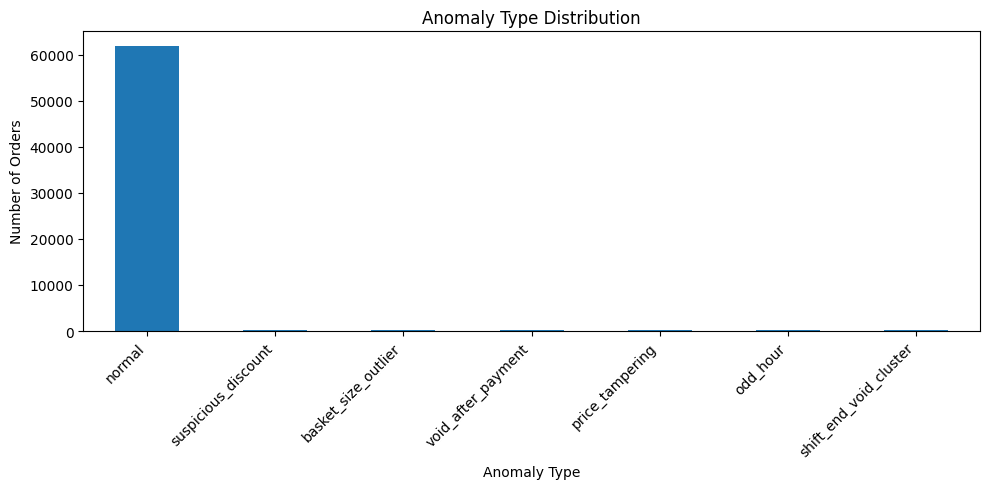

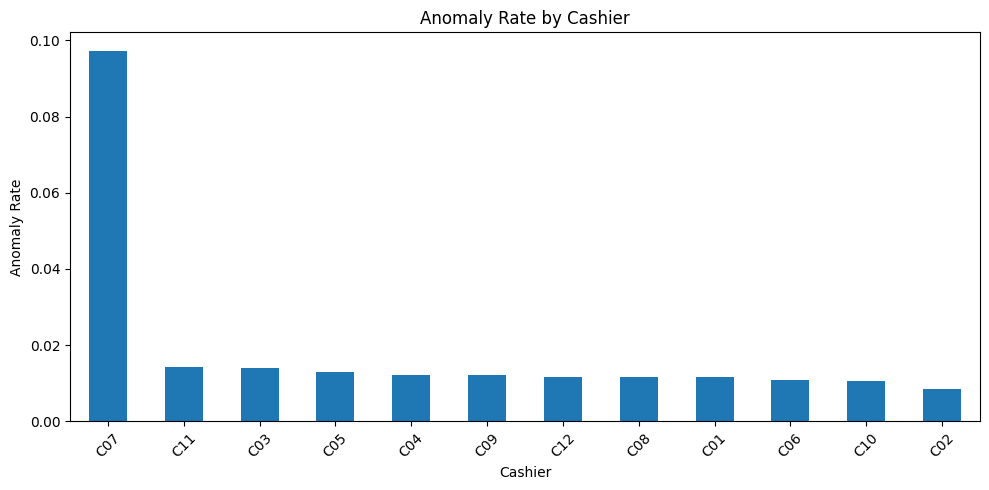

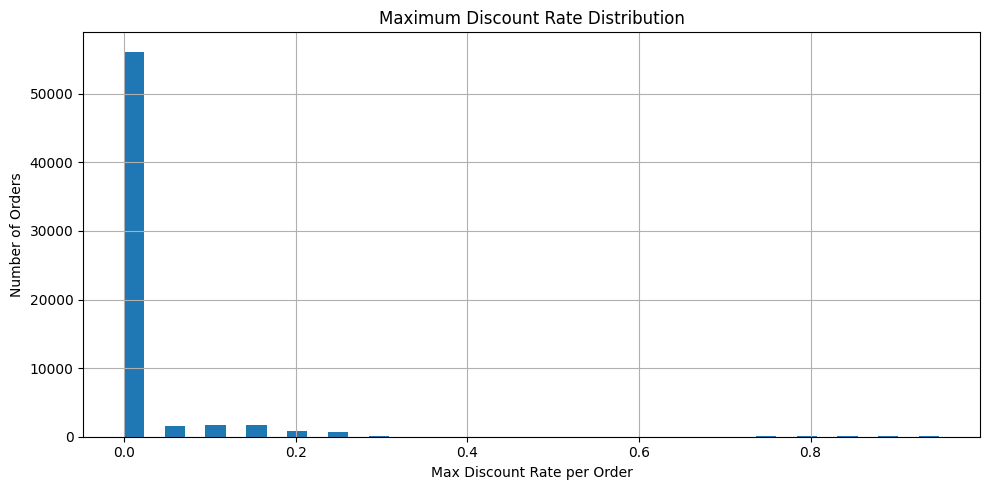

In [13]:
plt.figure(figsize=(10, 5))
orders['anomaly_type'].value_counts().plot(kind='bar')
plt.title('Anomaly Type Distribution')
plt.xlabel('Anomaly Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(Path(FIGURE_DIR) / 'anomaly_type_distribution.png', dpi=150)
plt.show()

cashier_rates = (
    orders.groupby('cashier_id')
    .agg(anomaly_rate=('is_anomaly', 'mean'), n_orders=('order_id', 'count'))
    .sort_values('anomaly_rate', ascending=False)
)

plt.figure(figsize=(10, 5))
cashier_rates['anomaly_rate'].plot(kind='bar')
plt.title('Anomaly Rate by Cashier')
plt.xlabel('Cashier')
plt.ylabel('Anomaly Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(Path(FIGURE_DIR) / 'anomaly_rate_by_cashier.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
orders['max_discount_rate'].clip(upper=1).hist(bins=40)
plt.title('Maximum Discount Rate Distribution')
plt.xlabel('Max Discount Rate per Order')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig(Path(FIGURE_DIR) / 'discount_distribution.png', dpi=150)
plt.show()

## 12. Save prepared dataset and schema

In [14]:
orders.to_csv(FEATURES_PATH, index=False)

with open(SCHEMA_PATH, 'w', encoding='utf-8') as f:
    json.dump(feature_schema, f, indent=2, ensure_ascii=False)

print('Saved prepared order-level dataset to:', FEATURES_PATH)
print('Saved feature schema to:', SCHEMA_PATH)
print('Final shape:', orders.shape)

Saved prepared order-level dataset to: ../Data Preparation/order_level_anomaly_dataset.csv
Saved feature schema to: ../Data Preparation/anomaly_feature_schema.json
Final shape: (63049, 77)


## 13. Final preview for Notebook 2

The next notebook will load:

```python
FEATURES_PATH = '../Module 3 Data Preparation/order_level_anomaly_dataset.csv'
SCHEMA_PATH = '../Module 3 Data Preparation/anomaly_feature_schema.json'
```

In [15]:
preview_cols = [
    'order_id', 'order_datetime', 'cashier_id', 'customer_id',
    'total_amount', 'basket_size', 'max_discount_rate', 'is_voided_order',
    'order_hour', 'is_odd_hour', 'is_anomaly', 'anomaly_type', 'split'
]
preview_cols = [c for c in preview_cols if c in orders.columns]
display(orders[preview_cols].head(10))

,order_id,order_datetime,cashier_id,customer_id,total_amount,basket_size,max_discount_rate,is_voided_order,order_hour,is_odd_hour,is_anomaly,anomaly_type,split
0,100009,2023-01-01 07:00:00,C01,453,8.75,2,0.0,False,7,0,0,normal,train
1,100000,2023-01-01 07:30:00,C02,520,16.50,3,0.0,False,7,0,0,normal,train
2,100005,2023-01-01 07:30:00,C01,4471,9.75,2,0.0,False,7,0,0,normal,train
3,100012,2023-01-01 07:30:00,C02,4488,17.50,4,0.0,False,7,0,0,normal,train
4,100001,2023-01-01 08:00:00,C03,6381,8.75,2,0.0,False,8,0,0,normal,train
5,100002,2023-01-01 08:00:00,C04,6422,15.50,4,0.0,False,8,0,0,normal,train
6,100004,2023-01-01 08:00:00,C03,4622,7.25,2,0.0,False,8,0,0,normal,train
7,100003,2023-01-01 08:30:00,C01,3973,11.25,3,0.0,False,8,0,0,normal,train
8,100007,2023-01-01 08:30:00,C02,8353,15.31,4,0.1,False,8,0,0,normal,train
9,100010,2023-01-01 08:30:00,C03,1222,11.50,3,0.0,False,8,0,0,normal,train
